# Conv1D Hybrid Autoencoder v2 -- Entrenamiento Final con Split por Bloques
## Dataset: SWaT A12 (Marzo 2026)

### Por que esta version existe

v1 usaba split cronologico 60/20/20 → scaler ajustado solo con la manana (09:02-13:00).
Al usar esos datos en el TSTR con datos de la tarde, los valores estaban fuera del rango
del scaler → train_loss de millones → modelos inutilizables.

**Esta version ajusta el scaler sobre el train del split por bloques intercalados.**
El nuevo scaler cubre distribuciones de todas las horas → rango valido para toda la sesion.
El GAN no se re-ejecuta: el TSTR usara synth_all_physical.npy + este nuevo scaler.


## 0. Imports

In [1]:
import json
import joblib
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

RAW_CSV    = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A12_OTDataset_Mar_26' / '11-Mar-2026_0900_1700_labeled.csv'
OPTUNA_CFG = PROJECT_ROOT / 'models' / 'detectors' / 'conv1d_hybrid_a12' / 'optuna_best_config.json'
SAVE_DIR   = PROJECT_ROOT / 'models' / 'detectors' / 'conv1d_hybrid_a12_v2'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT.resolve())
print('CSV:', RAW_CSV.exists())
print('Optuna:', OPTUNA_CFG.exists())
print('Save dir:', SAVE_DIR)


PROJECT_ROOT: C:\Users\j.manriquec\ics-synthetic-data-augmentation
CSV: True
Optuna: True
Save dir: c:\Users\j.manriquec\ics-synthetic-data-augmentation\models\detectors\conv1d_hybrid_a12_v2


## 2. Configuracion de Optuna

In [4]:
with open(OPTUNA_CFG) as f:
    optuna_cfg = json.load(f)

bp              = optuna_cfg['best_params']
continuous_cols = optuna_cfg['continuous_cols']
discrete_cols   = optuna_cfg['discrete_cols']
feature_cols    = optuna_cfg['feature_cols']
WINDOW_SIZE     = bp['window_size']
STRIDE          = bp['stride']
ALPHA           = float(bp['alpha'])

print(f'window_size: {WINDOW_SIZE} | stride: {STRIDE} | alpha: {ALPHA:.3f}')
print(f'continuous: {len(continuous_cols)} | discrete: {len(discrete_cols)}')
for k, v in bp.items(): print(f'  {k:<20}: {v}')


window_size: 30 | stride: 5 | alpha: 0.306
continuous: 31 | discrete: 31
  window_size         : 30
  stride              : 5
  n_conv_layers       : 1
  conv_channels_1     : 32
  conv_channels_2     : 8
  conv_channels_3     : 4
  kernel_size         : 5
  disc_hidden_1       : 64
  disc_hidden_2       : 32
  fusion_hidden       : 128
  dropout             : 0.18603688941537255
  batch_size          : 64
  lr                  : 0.0008622931547331273
  optimizer           : AdamW
  epochs              : 40
  alpha               : 0.30557233645075166


## 3. Carga y limpieza

In [5]:
df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw['t_stamp']      = pd.to_datetime(df_raw['t_stamp'], errors='coerce')
df_raw['attack_label'] = pd.to_numeric(df_raw['attack_label'], errors='coerce').fillna(0).astype(int)
df_raw = df_raw.sort_values('t_stamp').reset_index(drop=True)

df_all = df_raw[['t_stamp','attack_label'] + feature_cols].copy()
for col in feature_cols:
    df_all[col] = pd.to_numeric(df_all[col].replace('Bad Input', np.nan), errors='coerce')

WARMUP  = 120
df_work = df_all[df_all['attack_label'] == 0][['t_stamp'] + feature_cols].copy()
df_work = df_work[df_work['t_stamp'] >= df_work['t_stamp'].min() + pd.Timedelta(seconds=WARMUP)]
df_work = df_work.reset_index(drop=True)
print(f'Filas normales post-warmup: {len(df_work)}')


Filas normales post-warmup: 25620


## 4. Split por bloques intercalados (20 min)

In [6]:
BLOCK_MINUTES = 20

def block_interleaved_split(df_normal, block_minutes=20):
    df     = df_normal.copy().sort_values('t_stamp').reset_index(drop=True)
    t_min  = df['t_stamp'].min()
    df['_block'] = ((df['t_stamp'] - t_min).dt.total_seconds() // (block_minutes*60)).astype(int)

    blocks = sorted(df['_block'].unique())
    asgn   = {b: ('train' if i%5 in [0,1,2] else ('val' if i%5==3 else 'test'))
               for i,b in enumerate(blocks)}
    df['_split'] = df['_block'].map(asgn)

    splits = {s: df[df['_split']==s].drop(columns=['_split']).reset_index(drop=True)
              for s in ['train','val','test']}

    print(f'Bloques: {len(blocks)} de {block_minutes} min')
    for s in ['train','val','test']:
        n  = len(splits[s])
        bl = splits[s]['_block'].nunique()
        t0 = splits[s]['t_stamp'].min().strftime('%H:%M')
        t1 = splits[s]['t_stamp'].max().strftime('%H:%M')
        print(f'  {s:<6}: {n:6,} filas ({100*n/len(df):.1f}%) | {bl} bloques | {t0}-{t1}')

    print('Cobertura horaria:')
    for s in ['train','val','test']:
        h = sorted(splits[s]['t_stamp'].dt.hour.unique().tolist())
        print(f'  {s:<6}: {h}')

    return splits['train'], splits['val'], splits['test']


df_train, df_val, df_test = block_interleaved_split(df_work, BLOCK_MINUTES)


Bloques: 24 de 20 min
  train : 15,780 filas (61.6%) | 15 bloques | 09:02-16:41
  val   :  5,400 filas (21.1%) | 5 bloques | 10:02-17:00
  test  :  4,440 filas (17.3%) | 4 bloques | 10:22-15:41
Cobertura horaria:
  train : [9, 10, 11, 12, 13, 14, 15, 16]
  val   : [10, 11, 12, 13, 15, 16, 17]
  test  : [10, 12, 13, 14, 15]


In [7]:
# Imputar NaN con moda del TRAIN
modes_train = df_train[feature_cols].mode().iloc[0]
for df in [df_train, df_val, df_test]:
    df[feature_cols] = df[feature_cols].fillna(modes_train)
print(f'NaN tras imputacion: {df_train[feature_cols].isna().sum().sum()}')


NaN tras imputacion: 0


## 5. Nuevo scaler -- ajustado sobre train del split por bloques

El scaler v1 solo veia 09:02-13:00. El nuevo ve todas las horas de la sesion.
Los modelos posteriores (TSTR, validacion externa) usaran este scaler.
El GAN NO se re-ejecuta: el TSTR aplicara este scaler a synth_all_physical.npy.


In [8]:
# Ajustar scaler sobre el NUEVO train (todas las horas)
scaler_cont = StandardScaler()
scaler_cont.fit(df_train[continuous_cols].values)

# disc_max sobre el nuevo train
disc_max = df_train[discrete_cols].max().replace(0, 1)

def scale_df(df):
    df = df.copy()
    df[continuous_cols] = scaler_cont.transform(df[continuous_cols].values)
    df[discrete_cols]   = (df[discrete_cols] / disc_max).clip(0, 1)
    return df

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)
df_test_sc  = scale_df(df_test)

print('Escalado con nuevo scaler.')
print(f'Train cont: [{df_train_sc[continuous_cols].values.min():.2f}, '
      f'{df_train_sc[continuous_cols].values.max():.2f}]  (esperado: ~[-3, 3])')
print(f'Train disc: [{df_train_sc[discrete_cols].values.min():.2f}, '
      f'{df_train_sc[discrete_cols].values.max():.2f}]')


Escalado con nuevo scaler.
Train cont: [-7.72, 40.67]  (esperado: ~[-3, 3])
Train disc: [0.00, 1.00]


In [9]:
# Guardar scaler y disc_max para uso en TSTR y validacion externa
joblib.dump(scaler_cont,        SAVE_DIR / 'scaler_cont.pkl')
joblib.dump(disc_max.to_dict(), SAVE_DIR / 'disc_max_dict.pkl')
print('Guardados: scaler_cont.pkl, disc_max_dict.pkl')


Guardados: scaler_cont.pkl, disc_max_dict.pkl


## 6. Ventanas por bloque

In [10]:
def create_windows(arr, window_size, stride):
    wins = [arr[i:i+window_size] for i in range(0, len(arr)-window_size+1, stride)]
    if not wins: return np.empty((0,window_size,arr.shape[1]),dtype=np.float32)
    return np.array(wins, dtype=np.float32)


def summarize_discrete_windows(disc_windows, discrete_cols):
    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(discrete_cols):
            v = w[:, j]; s = pd.Series(v)
            feats[f'{col}__mode']        = s.mode().iloc[0] if len(s.mode())>0 else 0.0
            feats[f'{col}__transitions'] = float(np.sum(v[1:] != v[:-1]))
            feats[f'{col}__nunique']     = float(len(np.unique(v)))
            feats[f'{col}__dominance']   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)


def build_windows_per_block(df_sc, continuous_cols, discrete_cols,
                            window_size, stride, block_col='_block'):
    all_cont, all_disc = [], []
    for bid in sorted(df_sc[block_col].unique()):
        df_b = df_sc[df_sc[block_col]==bid].reset_index(drop=True)
        if len(df_b) < window_size: continue
        cw = create_windows(df_b[continuous_cols].values.astype(np.float32), window_size, stride)
        dw = create_windows(df_b[discrete_cols].values.astype(np.float32),   window_size, stride)
        if len(cw) == 0: continue
        all_cont.append(np.transpose(cw, (0,2,1)))
        all_disc.append(summarize_discrete_windows(dw, discrete_cols).values.astype(np.float32))
    if not all_cont: return None, None
    return np.concatenate(all_cont, 0), np.concatenate(all_disc, 0)


X_tr_c, X_tr_d = build_windows_per_block(df_train_sc, continuous_cols, discrete_cols, WINDOW_SIZE, STRIDE)
X_va_c, X_va_d = build_windows_per_block(df_val_sc,   continuous_cols, discrete_cols, WINDOW_SIZE, STRIDE)
X_te_c, X_te_d = build_windows_per_block(df_test_sc,  continuous_cols, discrete_cols, WINDOW_SIZE, STRIDE)

print(f'Train | cont: {X_tr_c.shape}  disc: {X_tr_d.shape}')
print(f'Val   | cont: {X_va_c.shape}  disc: {X_va_d.shape}')
print(f'Test  | cont: {X_te_c.shape}  disc: {X_te_d.shape}')


Train | cont: (3081, 31, 30)  disc: (3081, 124)
Val   | cont: (1055, 31, 30)  disc: (1055, 124)
Test  | cont: (868, 31, 30)  disc: (868, 124)


## 7. Arquitectura HybridConv1DAutoencoder

In [11]:
class HybridConv1DAutoencoder(nn.Module):
    def __init__(self, cont_channels, seq_len, disc_dim,
                 n_conv_layers=1, conv_channels_1=32, conv_channels_2=16, conv_channels_3=8,
                 kernel_size=3, disc_hidden_1=64, disc_hidden_2=32,
                 fusion_hidden=128, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        channels_list = [cont_channels]
        if n_conv_layers >= 1: channels_list.append(conv_channels_1)
        if n_conv_layers >= 2: channels_list.append(conv_channels_2)
        if n_conv_layers >= 3: channels_list.append(conv_channels_3)

        enc, cur = [], seq_len
        for i in range(len(channels_list)-1):
            enc += [nn.Conv1d(channels_list[i], channels_list[i+1],
                              kernel_size=kernel_size, padding=kernel_size//2),
                    nn.ReLU(), nn.Dropout(dropout), nn.MaxPool1d(2)]
            cur //= 2
        self.encoder_conv = nn.Sequential(*enc)
        self.reduced_len  = cur
        self.last_ch      = channels_list[-1]
        self.conv_flat    = self.last_ch * cur

        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden_1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden_1, disc_hidden_2), nn.ReLU())
        self.disc_hidden_2 = disc_hidden_2

        self.fusion = nn.Sequential(
            nn.Linear(self.conv_flat+disc_hidden_2, fusion_hidden),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_hidden, self.conv_flat+disc_hidden_2))

        rev = list(reversed(channels_list))
        dec = []
        for i in range(len(rev)-1):
            dec += [nn.ConvTranspose1d(rev[i],rev[i+1],kernel_size=2,stride=2),
                    nn.ReLU(), nn.Dropout(dropout)]
        dec.append(nn.Conv1d(rev[-1],rev[-1],kernel_size=kernel_size,padding=kernel_size//2))
        self.decoder_conv = nn.Sequential(*dec)
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden_2, disc_hidden_1), nn.ReLU(),
            nn.Linear(disc_hidden_1, disc_dim))

    def forward(self, xc, xd):
        hc  = self.encoder_conv(xc).view(xc.size(0), -1)
        hd  = self.encoder_disc(xd)
        f   = self.fusion(torch.cat([hc, hd], 1))
        hcd = f[:, :self.conv_flat].view(xc.size(0), self.last_ch, self.reduced_len)
        hdd = f[:, self.conv_flat:]
        oc  = self.decoder_conv(hcd)
        if oc.shape[2] != self.seq_len: oc = oc[:,:,:self.seq_len]
        return oc, self.decoder_disc(hdd)


def hybrid_loss(xc, xc_hat, xd, xd_hat, alpha):
    return alpha*nn.functional.mse_loss(xc_hat,xc) + (1-alpha)*nn.functional.mse_loss(xd_hat,xd)


model = HybridConv1DAutoencoder(
    cont_channels=X_tr_c.shape[1], seq_len=WINDOW_SIZE, disc_dim=X_tr_d.shape[1],
    n_conv_layers=int(bp['n_conv_layers']),
    conv_channels_1=int(bp['conv_channels_1']), conv_channels_2=int(bp['conv_channels_2']),
    conv_channels_3=int(bp['conv_channels_3']), kernel_size=int(bp['kernel_size']),
    disc_hidden_1=int(bp['disc_hidden_1']), disc_hidden_2=int(bp['disc_hidden_2']),
    fusion_hidden=int(bp['fusion_hidden']), dropout=float(bp['dropout'])
).to(device)

n_params = sum(p.numel() for p in model.parameters())
# Verificar shapes
_xc = torch.zeros(2, X_tr_c.shape[1], WINDOW_SIZE)
_xd = torch.zeros(2, X_tr_d.shape[1])
_oc, _od = model(_xc.to(device), _xd.to(device))
assert _oc.shape == _xc.shape
assert _od.shape == _xd.shape
print(f'Parametros: {n_params:,} | verificacion shapes OK')
del _xc, _xd, _oc, _od


Parametros: 163,807 | verificacion shapes OK


## 8. Entrenamiento con early stopping y checkpointing

In [12]:
BATCH_SIZE = int(bp['batch_size'])
LR         = float(bp['lr'])
MAX_EPOCHS = 150
PATIENCE   = 20

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_tr_c,dtype=torch.float32),
                  torch.tensor(X_tr_d,dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_va_c,dtype=torch.float32),
                  torch.tensor(X_va_d,dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6)

best_val, best_wts, no_improve, best_ep = float('inf'), None, 0, 1
train_hist, val_hist, lr_hist = [], [], []

print(f'Batch: {BATCH_SIZE} | LR: {LR:.2e} | MaxEp: {MAX_EPOCHS} | Patience: {PATIENCE}')
print()

for epoch in range(1, MAX_EPOCHS+1):
    model.train(); tl = 0.0
    for xc, xd in train_loader:
        xc, xd = xc.to(device), xd.to(device)
        optimizer.zero_grad()
        xc_hat, xd_hat = model(xc, xd)
        loss = hybrid_loss(xc, xc_hat, xd, xd_hat, ALPHA)
        loss.backward(); optimizer.step()
        tl += loss.item()
    tl /= len(train_loader)

    model.eval(); vl = 0.0
    with torch.no_grad():
        for xc, xd in val_loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat = model(xc, xd)
            vl += hybrid_loss(xc, xc_hat, xd, xd_hat, ALPHA).item()
    vl /= len(val_loader)

    scheduler.step(vl)
    train_hist.append(tl); val_hist.append(vl)
    lr_hist.append(optimizer.param_groups[0]['lr'])

    if vl < best_val - 1e-6:
        best_val = vl
        best_wts = {k: v.clone() for k,v in model.state_dict().items()}
        best_ep  = epoch; no_improve = 0
    else:
        no_improve += 1

    if epoch % 10 == 0:
        print(f'Ep {epoch:4d}/{MAX_EPOCHS} | Train: {tl:.5f} | Val: {vl:.5f} | '
              f'Best: {best_val:.5f} (ep {best_ep}) | LR: {optimizer.param_groups[0]["lr"]:.1e}')

    if no_improve >= PATIENCE:
        print(f'Early stopping ep {epoch}.')
        break

model.load_state_dict(best_wts)
model.eval()
print(f'Mejor val: {best_val:.6f} en ep {best_ep}')
gap = val_hist[best_ep-1] / max(train_hist[best_ep-1], 1e-10)
print(f'Gap val/train: {gap:.1f}x')


Batch: 64 | LR: 8.62e-04 | MaxEp: 150 | Patience: 20

Ep   10/150 | Train: 0.08046 | Val: 1.07565 | Best: 1.07565 (ep 10) | LR: 8.6e-04
Ep   20/150 | Train: 0.05644 | Val: 0.93637 | Best: 0.93637 (ep 20) | LR: 8.6e-04
Ep   30/150 | Train: 0.04192 | Val: 0.42453 | Best: 0.39972 (ep 28) | LR: 8.6e-04
Ep   40/150 | Train: 0.03799 | Val: 0.43915 | Best: 0.36023 (ep 36) | LR: 8.6e-04
Ep   50/150 | Train: 0.03382 | Val: 0.45314 | Best: 0.33746 (ep 49) | LR: 8.6e-04
Ep   60/150 | Train: 0.03229 | Val: 0.37426 | Best: 0.28322 (ep 58) | LR: 8.6e-04
Ep   70/150 | Train: 0.03053 | Val: 0.33759 | Best: 0.28322 (ep 58) | LR: 4.3e-04
Early stopping ep 78.
Mejor val: 0.283221 en ep 58
Gap val/train: 8.8x


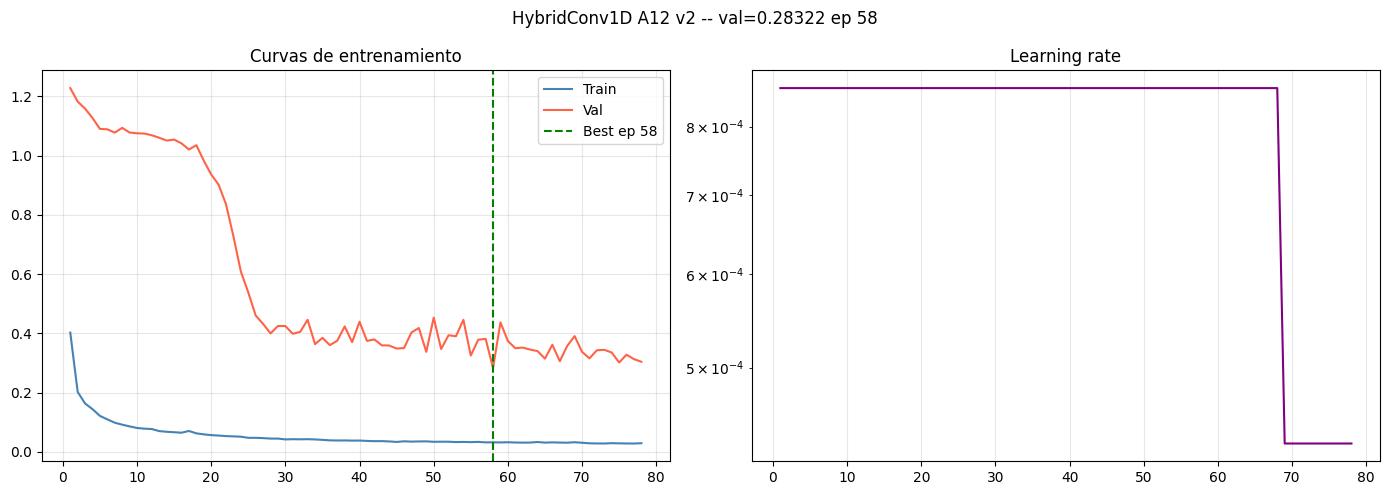

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
er = range(1, len(train_hist)+1)
axes[0].plot(er, train_hist, label='Train', color='steelblue', lw=1.5)
axes[0].plot(er, val_hist,   label='Val',   color='tomato',    lw=1.5)
axes[0].axvline(best_ep, color='green', linestyle='--', lw=1.5, label=f'Best ep {best_ep}')
axes[0].set_title('Curvas de entrenamiento'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(er, lr_hist, color='purple', lw=1.5)
axes[1].set_yscale('log'); axes[1].set_title('Learning rate'); axes[1].grid(True, alpha=0.3)
plt.suptitle(f'HybridConv1D A12 v2 -- val={best_val:.5f} ep {best_ep}', fontsize=12)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'training_curve.png'), dpi=120, bbox_inches='tight')
plt.show()


## 9. Errores de reconstruccion y umbrales

In [14]:
def recon_errors(model, Xc, Xd, alpha, batch_size=256):
    loader = DataLoader(
        TensorDataset(torch.tensor(Xc,dtype=torch.float32),
                      torch.tensor(Xd,dtype=torch.float32)),
        batch_size=batch_size, shuffle=False)
    ec_l, ed_l = [], []
    model.eval()
    with torch.no_grad():
        for xc, xd in loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat = model(xc, xd)
            ec_l.extend(torch.mean((xc_hat-xc)**2, dim=(1,2)).cpu().numpy())
            ed_l.extend(torch.mean((xd_hat-xd)**2, dim=1).cpu().numpy())
    ec = np.array(ec_l); ed = np.array(ed_l)
    return ec, ed, alpha*ec+(1-alpha)*ed


err_tr_c,err_tr_d,err_tr = recon_errors(model,X_tr_c,X_tr_d,ALPHA)
err_va_c,err_va_d,err_va = recon_errors(model,X_va_c,X_va_d,ALPHA)
err_te_c,err_te_d,err_te = recon_errors(model,X_te_c,X_te_d,ALPHA)

print(f"{'Split':<8} {'Mean':>8} {'Std':>8} {'p90':>8} {'p95':>8} {'p99':>8}")
print('-'*50)
for name, err in [('Train',err_tr),('Val',err_va),('Test',err_te)]:
    print(f'{name:<8} {err.mean():>8.5f} {err.std():>8.5f} '
          f'{np.percentile(err,90):>8.5f} {np.percentile(err,95):>8.5f} '
          f'{np.percentile(err,99):>8.5f}')


Split        Mean      Std      p90      p95      p99
--------------------------------------------------
Train     0.02430  0.04639  0.03619  0.08237  0.20842
Val       0.28489  0.80517  0.17597  3.39099  3.56415
Test      0.04300  0.02800  0.08057  0.10061  0.13345


In [15]:
PERCENTILES = [90, 95, 97.5, 99, 99.5]
tau_dict = {f'p{str(p).replace(".","_")}': float(np.percentile(err_te, p)) for p in PERCENTILES}

print('Umbrales sobre test normal:')
for k, v in tau_dict.items():
    far = (err_te > v).mean()
    print(f'  {k:8s}: {v:.6f}  FAR={100*far:.2f}%')


Umbrales sobre test normal:
  p90     : 0.080573  FAR=10.02%
  p95     : 0.100608  FAR=5.07%
  p97_5   : 0.109360  FAR=2.53%
  p99     : 0.133451  FAR=1.04%
  p99_5   : 0.159355  FAR=0.58%


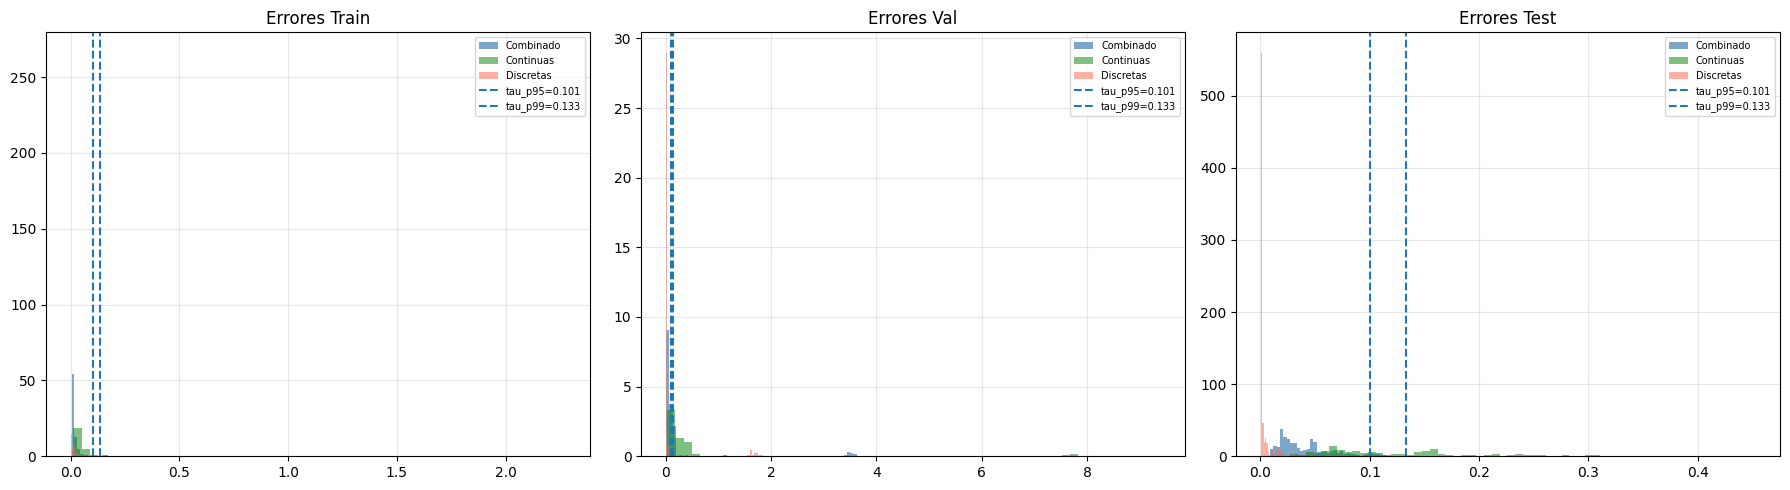

In [16]:
fig, axes = plt.subplots(1,3,figsize=(18,5))
for ax,(name,ec,ed,ecomb) in zip(axes,[
        ('Train',err_tr_c,err_tr_d,err_tr),
        ('Val',  err_va_c,err_va_d,err_va),
        ('Test', err_te_c,err_te_d,err_te)]):
    ax.hist(ecomb,bins=60,alpha=0.7,color='steelblue',density=True,label='Combinado')
    ax.hist(ec,   bins=60,alpha=0.5,color='green',    density=True,label='Continuas')
    ax.hist(ed,   bins=60,alpha=0.5,color='tomato',   density=True,label='Discretas')
    for k,v in tau_dict.items():
        if k in ['p95','p99']: ax.axvline(v,linestyle='--',lw=1.5,label=f'tau_{k}={v:.3f}')
    ax.set_title(f'Errores {name}'); ax.legend(fontsize=7); ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(str(SAVE_DIR/'error_distributions.png'),dpi=120,bbox_inches='tight')
plt.show()


## 10. Guardar artefactos

In [17]:
torch.save(model.state_dict(), SAVE_DIR / 'model_state.pt')

with open(SAVE_DIR / 'tau_dict.json', 'w') as f:
    json.dump(tau_dict, f, indent=4)
with open(SAVE_DIR / 'columns_config.json', 'w') as f:
    json.dump({'continuous_cols':continuous_cols,'discrete_cols':discrete_cols,
               'feature_cols':feature_cols}, f, indent=4)

config = {
    'version': 'a12_final_v2_block_split',
    'dataset': 'SWaT A12 Mar 2026',
    'split': 'block_interleaved_20min',
    'block_minutes': BLOCK_MINUTES,
    'warmup_seconds': WARMUP,
    'n_normal_rows': len(df_work),
    'n_train': len(df_train), 'n_val': len(df_val), 'n_test': len(df_test),
    'window_size': WINDOW_SIZE, 'stride': STRIDE, 'alpha': float(ALPHA),
    'best_epoch': best_ep, 'best_val_loss': float(best_val),
    'train_loss_at_best': float(train_hist[best_ep-1]),
    'n_windows_train': int(len(X_tr_c)),
    'n_windows_val':   int(len(X_va_c)),
    'n_windows_test':  int(len(X_te_c)),
    'cont_channels': int(X_tr_c.shape[1]),
    'disc_dim':       int(X_tr_d.shape[1]),
    'continuous_cols': continuous_cols, 'discrete_cols': discrete_cols,
    'feature_cols': feature_cols,
    'scenarios': ['real_only','synthetic_only','real_plus_synthetic'],
    'model_params': {k:(float(v) if isinstance(v,float) else v) for k,v in bp.items()},
    'tau_dict': tau_dict,
    'error_stats': {
        'test_mean': float(err_te.mean()), 'test_std': float(err_te.std()),
        'test_p90': float(np.percentile(err_te,90)),
        'test_p95': float(np.percentile(err_te,95)),
        'test_p99': float(np.percentile(err_te,99)),
    }
}
with open(SAVE_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=4)

print('Artefactos guardados en:', SAVE_DIR.resolve())
for fp in sorted(SAVE_DIR.iterdir()): print(f'  {fp.name}')


Artefactos guardados en: C:\Users\j.manriquec\ics-synthetic-data-augmentation\models\detectors\conv1d_hybrid_a12_v2
  columns_config.json
  config.json
  disc_max_dict.pkl
  error_distributions.png
  model_state.pt
  scaler_cont.pkl
  tau_dict.json
  training_curve.png
